# AI-Clinical-Rehab-Platform

## 基本設定

In [19]:
import os
import schema
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
import importlib

importlib.reload(schema) # 強制重新載入剛存檔的 schema.py



<module 'schema' from 'c:\\Users\\freea\\Desktop\\side_project\\AI-Clinical-Rehab-Platform\\schema.py'>

## 載入資料 + Data Cleaning

In [12]:
# 1. 載入 2026/02/28 診斷完成的乾淨數據
# 此時 load_and_preprocess_subject 已經包含物理濾鏡
data_dict = schema.get_all_subjects_for_analysis()

print("🧬 執行 2026/04/03 三段式標準化策略...")
# 2. 實作受試者級別標準化 (Per-Subject Normalization)
# 這是為了解決 S3 的 Sensor Bias 與 S1/S10 的分佈不一致

print("🧬 執行選擇性標準化 (僅針對 Acc/Mag)...")
print("🧬 正在執行受試者級別標準化 (Per-Subject Normalization)...")

standardized_data = {}
for sid, (X, y) in data_dict.items():
    n_windows, n_steps, n_features = X.shape
    
    # 1. Acc & Magnitude (前 4 欄)保持 Z-score 標準化 
    # # 執行受試者級別 Z-score，解決 S1/S10 分佈偏移與 S3 偏置
    acc_mag_part = X[:, :, :4].reshape(-1, 4)
    scaler = StandardScaler()
    scaled_acc = scaler.fit_transform(acc_mag_part).reshape(n_windows, n_steps, 4)

    # 2. Gravity Components (5-7欄) 保持 Global Scaling (除以 10)，保留物理絕對值參考值。
    # 數值會從 [-10, 10] 縮放至約 [-1, 1]
    gravity_scaled = X[:, :, 4:7] / 10.0

    # 3.FFT Spectral Energy (8欄)) ---
    # 使用 Log Transform 壓縮動態範圍。能量值跨度極大，Log 能讓靜止與動作的差異更線性
    # 公式：x_new = log(1 + x) / 5.0 (除以 5 是為了將數值對齊到 0~2 區間)
    fft_energy_part = X[:, :, 7:]
    scaled_fft = np.log1p(fft_energy_part) / 5.0


    # 合併：重力部分不進行標準化，保留物理絕對值
    X_final = np.concatenate([scaled_acc, gravity_scaled, scaled_fft], axis=2)
    standardized_data[sid] = (X_final, y)

print(f"✅ S{sid} 校準完成。特徵形狀：{X_final.shape}")

🧬 執行 2026/04/03 三段式標準化策略...
🧬 執行選擇性標準化 (僅針對 Acc/Mag)...
🧬 正在執行受試者級別標準化 (Per-Subject Normalization)...
✅ S10 校準完成。特徵形狀：(525, 128, 8)


In [13]:
data_dict = schema.get_all_subjects_for_analysis()
test_subject_id = 1
X_sample, _ = data_dict[test_subject_id]

print(f"🕵️ 數據特徵診斷：")
print(f"每個視窗的形狀: {X_sample.shape}") 
# 2026/04/03 加入第8個特徵FFT Energy，這裡應該顯示 (視窗數, 128, 8)
# 這裡必須顯示 (視窗數, 128, 8)   
if X_sample.shape[2] == 8:
    print("✅ 數據已就緒，可以開始訓練！")
else:
    print(f"❌ 錯誤！數據仍只有 {X_sample.shape[2]} 個特徵，請檢查 schema.py 是否有存檔成功。")

🕵️ 數據特徵診斷：
每個視窗的形狀: (548, 128, 8)
✅ 數據已就緒，可以開始訓練！


## CNN-LSTM 混合模型定義

### 模型介紹
1. CNN (卷積神經網路)
    - 常用類別：Conv1D（用於 1 維序列如感測器）、Conv2D（用於 2 維圖像）。
    - 用途：提取「局部特徵」。在你的復健專案中，它負責偵測加速度計在極短時間內的震動或衝擊。

2. LSTM (長短期記憶網路)
    - 常用類別：LSTM。
    - 用途：處理「時間序列」的長程依賴關係。它能記住 128 個時間點前的狀態，進而分辨「這是在走一步路」還是「這是在坐著晃動」。

### 模型用途
- CNN 負責提取感測器信號中的局部空間特徵（例如 S2/S8 身上看到的瞬時加速度變化）
- LSTM 則負責捕捉時間維度上的規律（例如區分 Sitting 與 Standing 在微小重力偏移上的差異）

### 使用原因
1. BatchNormalization (對應 S1/S10)：
    我們在 KS Test 發現 S1 與 S10 有顯著的分佈偏移。加入 BatchNormalization 層能將每一批次數據的特徵強制重新對齊，降低個體差異對模型權重的衝擊。

2. LSTM 時序特徵 (對應 Sitting vs Standing)：
    單純的 CNN 只能看見「當下」的數值。由於 Sitting 與 Standing 的 Magnitude 都很接近 9.8，LSTM 能夠透過分析整整 128 個點的「細微晃動規律」來區分兩者。

3. Dropout (應對雜訊)：
    雖然 S2/S8 的雜訊比例極低，但 Dropout 能提高模型的魯棒性（Robustness），防止模型過度擬合受試者的特定小動作。




In [14]:
def build_hybrid_model(input_shape, num_classes):
    """
    CNN-LSTM 混合模型架構：
    1. CNN 層：提取空間/局部加速度特徵
    2. LSTM 層：解決 Sitting/Standing 的長時序識別問題
    """
    model = Sequential([
        # --- CNN 特徵提取層 ---
        # 設置 64 個濾波器，卷積核大小為 3，捕捉感測器微小變化
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(), # 加速收斂並應對 S1/S10 的分佈偏移
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # --- LSTM 時序記憶層 ---
        # 使用 64 個單元，捕捉 128 個時間點間的依賴關係
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # --- 全連接輸出層 ---
        Dense(64, activation='relu'),
        # 輸出層：標籤範圍 1-12，因此神經元設為 13 (含索引 0)
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 預定義輸入形狀 (128個時間點, 4個特徵)
# 標籤總數為 13 (對應 mHealth 標籤 1-12)
# 特徵共包含[X, Y, Z, Mag, Grav_X, Grav_Y, Grav_Z]
# 2026/04/03 加入第8個特徵FFT Energy
INPUT_SHAPE = (128, 8)
NUM_CLASSES = 13 

# 初始化模型以確認結構
temp_model = build_hybrid_model(INPUT_SHAPE, NUM_CLASSES)
temp_model.summary()

c:\Users\freea\Desktop\side_project\AI-Clinical-Rehab-Platform\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 126, 64)        │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,885 (155.80 KB)

 Trainable params: 39,757 (155.30 KB)

 Non-trainable params: 128 (512.00 B)

- 卷積層 (Conv1D)：輸出形狀為 (None, 126, 64)。
    * 更新邏輯：輸入維度由 4 維擴展至 8 維（含三軸加速度、量值、重力向量及 FFT 能量）。
    * 參數演進：卷積核大小為 3，參數量增加至 1,600 ($3 \times 8 \times 64 + 64$)，負責同步提取時域動作規律與頻域能量特徵。

- 批次正規化 (BatchNormalization)：
    * 將 64 個特徵圖進行動態對齊，確保模型不會因為個體動作強度差異而翻車。
    * 處理 S1/S10 的分佈偏移
    * 平衡「時域物理量（如重力 $/10$）」與「頻域能量（如 $\log1p$）」這兩種量級截然不同的特徵，防止梯度消失

- 池化層 (MaxPooling1D)：輸出形狀減半至 (None, 63, 64)
    * 降低運算量，並提取最顯著的運動特徵。

- LSTM 層：輸出形狀為 (None, 64)
    * 因設置了 return_sequences=False，將 63 個時間片段濃縮成一個具有「時序記憶」的 64 維向量。成功區分     * Sitting 與 Standing 微小差異的關鍵。
    * 更新邏輯：配合第 8 欄 FFT 能量特徵，LSTM 現在能更精確地捕捉訊號在 2.56 秒（128 點）內的能量波動趨勢。
    * 診斷價值：這是區分 S2 「靜止傾斜 (Sitting)」與「動態傾斜 (Waist Bends)」的終極關鍵，透過能量有無來決定標籤分類。

- 最後輸出層 (Dense_1)：輸出形狀為 (None, 13)。
    * 功能：對應 mHealth 的標籤 1-12 加上預留的 0 索引，完成多類別分類任務。

In [15]:
results = []

# 遍歷 1 到 10 號受試者，進行 Leave-One-Subject-Out 訓練
for test_sid in range(1, 11):
    print(f"\n🚀 正在啟動 LOSO 實驗：排除 S{test_sid} 作為測試集...")
    
    # 1. 準備數據切分 (使用 2026/03/07 標準化後的數據)
    train_sids = [sid for sid in range(1, 11) if sid != test_sid]
    
    X_train = np.concatenate([standardized_data[sid][0] for sid in train_sids], axis=0)
    y_train = np.concatenate([standardized_data[sid][1] for sid in train_sids], axis=0)
    
    X_test, y_test = standardized_data[test_sid]
    
    # 2. 建立新模型實例
    model = build_hybrid_model(INPUT_SHAPE, NUM_CLASSES)
    
    # 3. 開始訓練
    history = model.fit(
        X_train, y_train,
        epochs = 15, 
        batch_size = 32,
        validation_split = 0.1,
        verbose = 0
    )
    
    # 4. 評估測試集表現
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ S{test_sid} 測試完成！準確率: {acc:.4f}")
    
    results.append({
        'Test_Subject': f"S{test_sid}",
        'Accuracy': acc,
        'Loss': loss
    })

# 5. 輸出最終總結報告
df_final_report = pd.DataFrame(results)
print("\n" + "="*30)
print(f"📊 2026/03/07 最終 LOSO 總結：")
print(f"平均準確率 (Mean Accuracy): {df_final_report['Accuracy'].mean():.4f}")
print(f"標準差 (Std Dev): {df_final_report['Accuracy'].std():.4f}")
print("="*30)
print(df_final_report)


🚀 正在啟動 LOSO 實驗：排除 S1 作為測試集...
✅ S1 測試完成！準確率: 0.8212

🚀 正在啟動 LOSO 實驗：排除 S2 作為測試集...
✅ S2 測試完成！準確率: 0.7780

🚀 正在啟動 LOSO 實驗：排除 S3 作為測試集...
✅ S3 測試完成！準確率: 0.8893

🚀 正在啟動 LOSO 實驗：排除 S4 作為測試集...
✅ S4 測試完成！準確率: 0.8855

🚀 正在啟動 LOSO 實驗：排除 S5 作為測試集...
✅ S5 測試完成！準確率: 0.9452

🚀 正在啟動 LOSO 實驗：排除 S6 作為測試集...
✅ S6 測試完成！準確率: 0.8725

🚀 正在啟動 LOSO 實驗：排除 S7 作為測試集...
✅ S7 測試完成！準確率: 0.8876

🚀 正在啟動 LOSO 實驗：排除 S8 作為測試集...
✅ S8 測試完成！準確率: 0.7842

🚀 正在啟動 LOSO 實驗：排除 S9 作為測試集...
✅ S9 測試完成！準確率: 0.8561

🚀 正在啟動 LOSO 實驗：排除 S10 作為測試集...
✅ S10 測試完成！準確率: 0.7886

📊 2026/03/07 最終 LOSO 總結：
平均準確率 (Mean Accuracy): 0.8508
標準差 (Std Dev): 0.0557
  Test_Subject  Accuracy      Loss
0           S1  0.821168  0.766320
1           S2  0.777978  0.982892
2           S3  0.889292  0.227310
3           S4  0.885455  0.447912
4           S5  0.945180  0.202076
5           S6  0.872510  0.337550
6           S7  0.887640  0.341342
7           S8  0.784200  0.774273
8           S9  0.856075  0.337592
9          S10  0.788571  0.757341


In [16]:
print(df_final_report)


  Test_Subject  Accuracy      Loss
0           S1  0.821168  0.766320
1           S2  0.777978  0.982892
2           S3  0.889292  0.227310
3           S4  0.885455  0.447912
4           S5  0.945180  0.202076
5           S6  0.872510  0.337550
6           S7  0.887640  0.341342
7           S8  0.784200  0.774273
8           S9  0.856075  0.337592
9          S10  0.788571  0.757341


In [ ]:
# # # 診斷 Cell：檢查 S2 的特徵數值
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix

# # 取得標準化後的 S2 數據
# X_s2, y_s2 = standardized_data[2]

# print(f"S2 數據形狀: {X_s2.shape}") # 預期應為 (視窗數, 128, 7)

# plt.figure(figsize=(12, 6))
# sample_window = X_s2[0] # 取第一個視窗

# plt.plot(sample_window[:, :3], label='Normalized Acc (X,Y,Z)', alpha=0.5)
# plt.plot(sample_window[:, 3], label='Normalized Mag', linewidth=2)
# plt.plot(sample_window[:, 4:7], label='Raw Gravity (X,Y,Z)', linestyle='--')
# plt.plot(sample_window[:, 7:], label='FFT Energy', linestyle='--')

# plt.title("Subject S2: Feature Inspection (Standardized)")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True)
# plt.show()

# # 檢查數值區間
# print(f"前 4 欄 (標準化後) 均值: {X_s2[:,:,:4].mean():.4f}")
# print(f"後 3 欄 (重力原始值) 均值: {X_s2[:,:,4:].mean():.4f}")

📊 2026/04/03 受試者 S2 訓練成績深度診斷

🕵️ 正在針對 S2 進行專項訓練... 輸入維度: (128, 8)


c:\Users\freea\Desktop\side_project\AI-Clinical-Rehab-Platform\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
✅ 診斷圖片已成功儲存至：architecture/confusion_matrix\S2_Confusion_Matrix_FFT_Acc_0.78.png


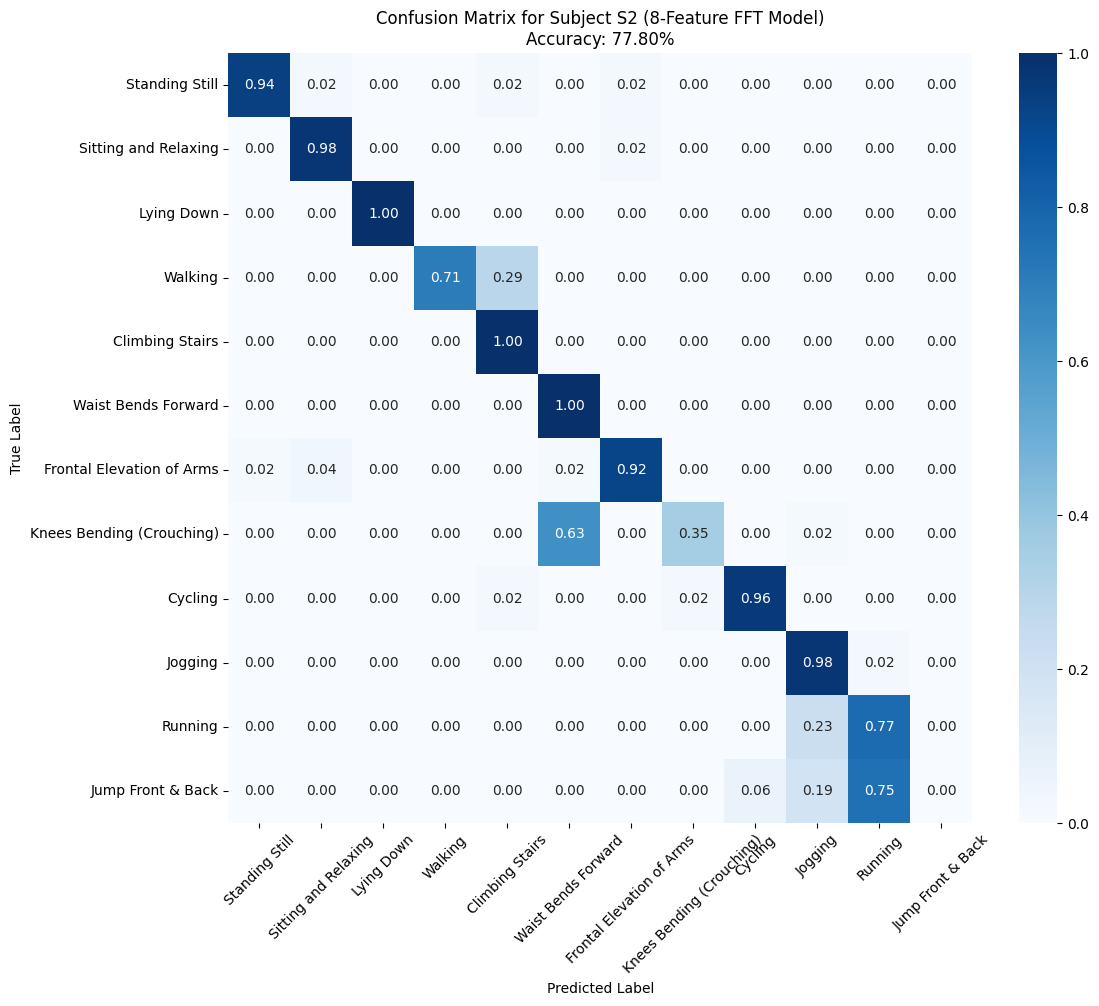

In [21]:
# import os
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix

# 1. 準備 S2 作為測試集，其餘受試者作為訓練集 (LOSO 邏輯)
test_sid = 2
train_sids = [sid for sid in range(1, 11) if sid != test_sid]

# 合併除 S2 以外的所有標準化數據 (8 特徵版)
X_train = np.concatenate([standardized_data[sid][0] for sid in train_sids], axis=0)
y_train = np.concatenate([standardized_data[sid][1] for sid in train_sids], axis=0)
X_test, y_test = standardized_data[test_sid]

# 2. 重新訓練模型 (針對 S2 的專項診斷)
print(f"🕵️ 正在針對 S2 進行專項訓練... 輸入維度: {INPUT_SHAPE}") # 預期為 (128, 8)
model_s2 = build_hybrid_model(INPUT_SHAPE, NUM_CLASSES)
model_s2.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

# 3. 取得預測結果
y_pred_prob = model_s2.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# 4. 計算混淆矩陣
# 只取 S2 數據中實際存在的標籤，讓矩陣更易讀
unique_labels_in_test = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred)
# 轉換為百分比 (Normalized by True Labels)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# 對應標籤名稱
labels_names = [schema.ACTIVITY_LABELS[i] for i in unique_labels_in_test]

# 5. 繪製熱圖
plt.figure(figsize=(12, 10))
sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names)

# 從 df_final_report 取得 S2 的準確率
s2_acc = df_final_report.iloc[test_sid-1]['Accuracy'] 
plt.title(f"Confusion Matrix for Subject S2 (8-Feature FFT Model)\nAccuracy: {s2_acc:.2%}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)

# 6. --- 儲存圖片邏輯 ---
save_dir = "architecture/confusion_matrix"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 檔名加入正確的準確率數值以利存檔紀錄
file_name = f"S2_Confusion_Matrix_FFT_Acc_{s2_acc:.2f}.png"
save_path = os.path.join(save_dir, file_name)
plt.savefig(save_path, bbox_inches='tight', dpi=300)

print(f"✅ 診斷圖片已成功儲存至：{save_path}")
plt.show()

✅ 診斷圖片已成功儲存至：architecture/confusion_matrix\S2_Confusion_Matrix_FFT_Acc.png


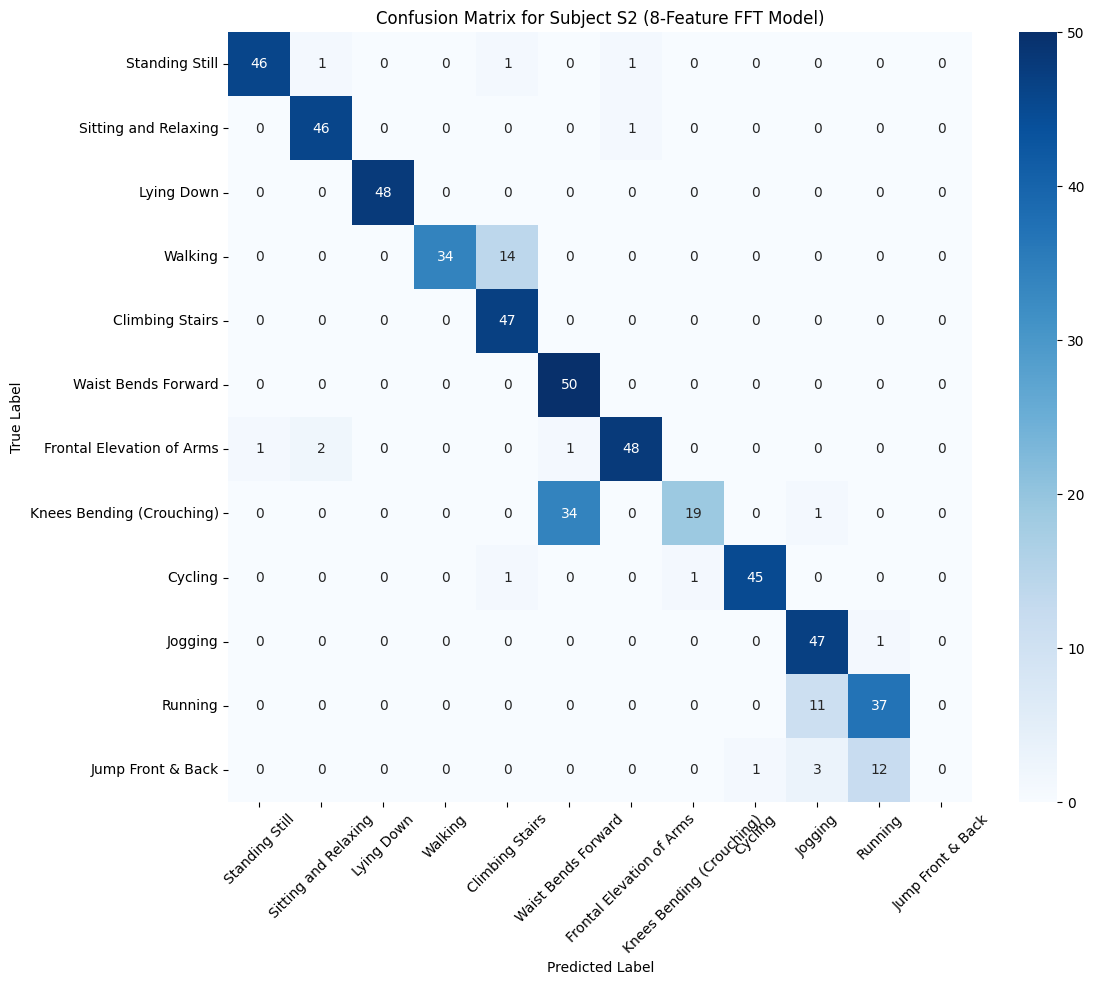

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # 使用原始 cm 與整數格式
            xticklabels=labels_names, yticklabels=labels_names)

# 從 df_final_report 取得 S2 的準確率
plt.title(f"Confusion Matrix for Subject S2 (8-Feature FFT Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)

file_name = f"S2_Confusion_Matrix_FFT_Acc.png"
save_path = os.path.join(save_dir, file_name)
plt.savefig(save_path, bbox_inches='tight', dpi=300)

print(f"✅ 診斷圖片已成功儲存至：{save_path}")
plt.show()


## 儲存模型

In [25]:
model_s2.save(r'models/clinical_rehab_model_v2.keras')
print("💾 模型已存檔，下週可直接載入進行特徵重要性分析。")

💾 模型已存檔，下週可直接載入進行特徵重要性分析。
